In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as matt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')

nhts = pd.read_csv("NHTS(in).csv")

nhts.head()

,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014


# Bar Chart

A bar chart comparing categories within a specific variable 

<Figure size 2000x1000 with 0 Axes>

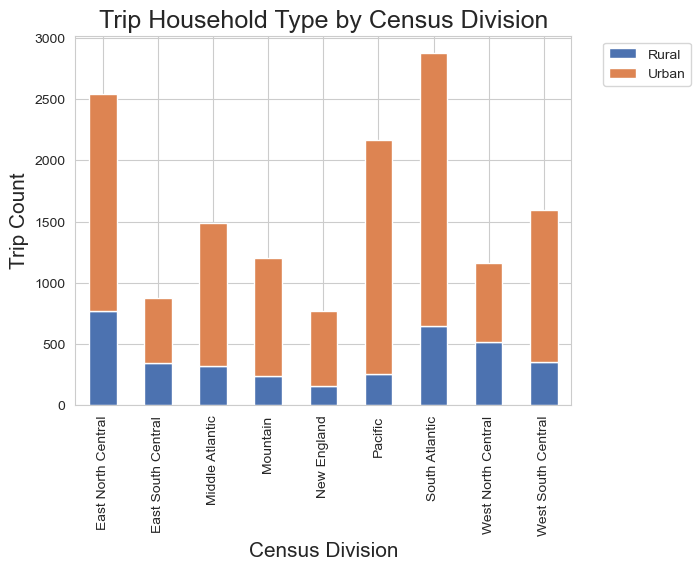

In [2]:
# Grouping and counting by 'census_division' and 'household_location'
dataGrouped = nhts.groupby(['census_division','household_location']).size().unstack(fill_value = 0)

matt.figure(figsize = (20,10))

dataGrouped.plot(kind = 'bar', stacked = True)
matt.title('Trip Household Type by Census Division', fontsize = 18)
matt.ylabel('Trip Count', fontsize = 15)
matt.xlabel('Census Division', fontsize = 15)

matt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.5)



# Histogram

A histogram showing the distribution of a specific variable 

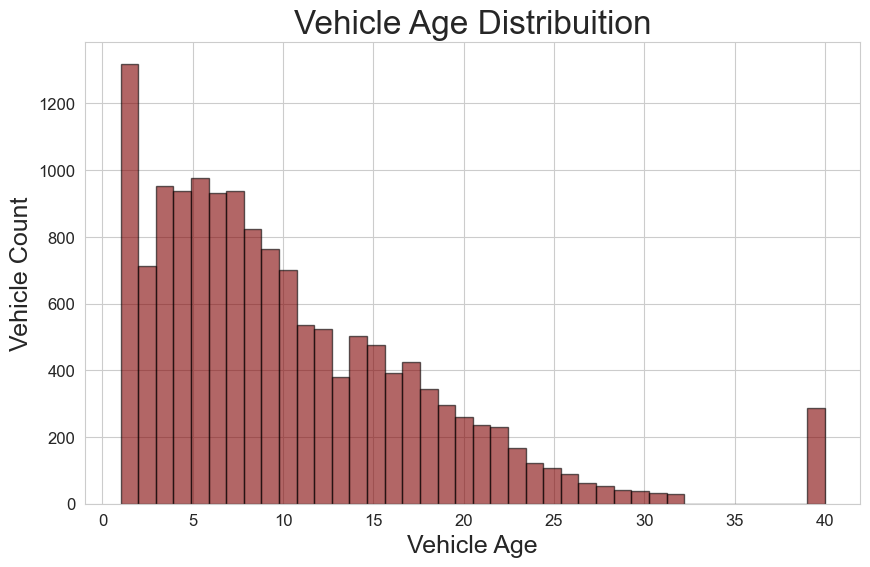

In [3]:
matt.figure(figsize = (10,6))

matt.hist(nhts['vehicle_age'], bins = 40, color = 'maroon', edgecolor = 'black', alpha = 0.6)

matt.title('Vehicle Age Distribuition', fontsize = 24)
matt.xlabel('Vehicle Age', fontsize = 18)
matt.ylabel('Vehicle Count', fontsize = 18)
matt.xticks(fontsize = 12)
matt.yticks(fontsize = 12)


matt.show()

# Boxplot
A boxplot showing the distribution of a variable in each category 

<Figure size 1400x800 with 0 Axes>

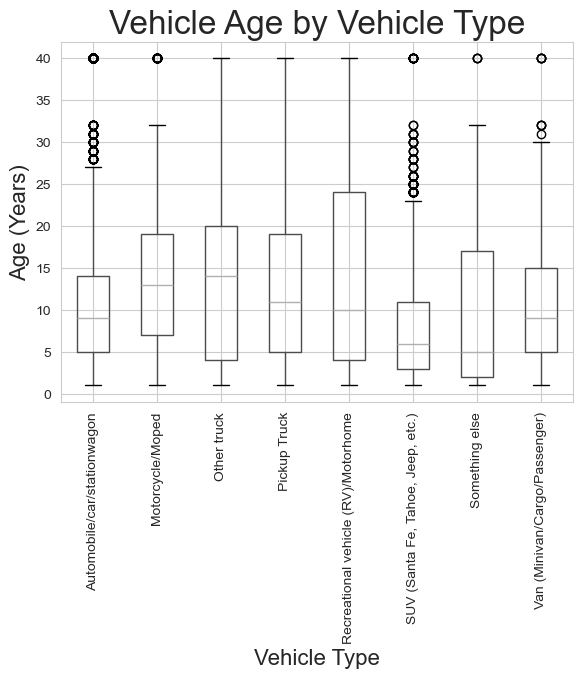

In [4]:

matt.figure(figsize = (14,8))


nhts.boxplot(column = 'vehicle_age', by = 'vehicle_type')


matt.xticks(rotation = 90)

matt.xlabel('Vehicle Type', fontsize = 16)
matt.ylabel('Age (Years)', fontsize = 16)

matt.suptitle('')
matt.title('Vehicle Age by Vehicle Type', fontsize = 24)

matt.show()



# Time-Series Plots
At least two different time-series plots showing and analyzing driving behavior 

In [5]:
ngsim = pd.read_csv('NGSIM(in).csv')

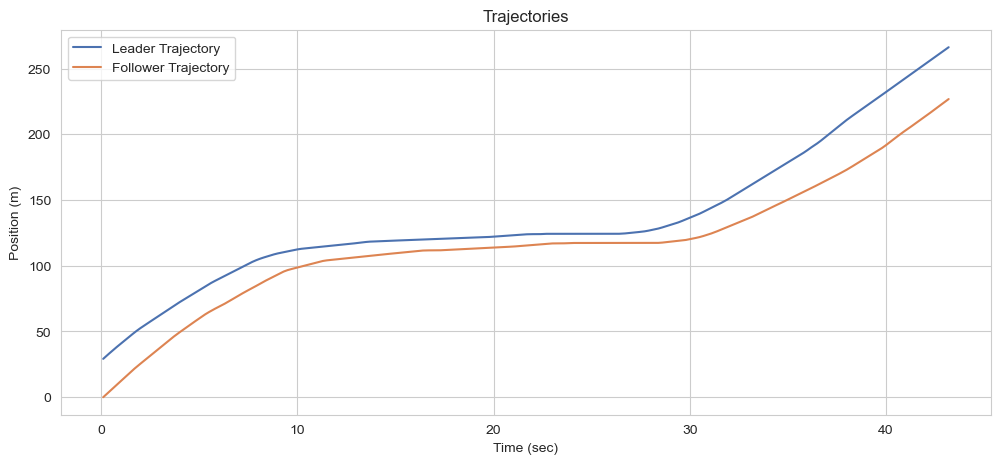

In [6]:
# Select a trajectory number
trajectory_number =  10

# select the data based on the subset 
trajectory = ngsim[ngsim['trajectory_number'] == trajectory_number]

matt.figure(figsize = (12,5))
sns.lineplot(data = trajectory, x = 'Time', y = 'leader_position(m)', label = 'Leader Trajectory')
sns.lineplot(data = trajectory, x = 'Time', y = 'follower_position(m)', label = 'Follower Trajectory')

matt.xlabel('Time (sec)')
matt.ylabel('Position (m)')
matt.title('Trajectories')
matt.legend()
matt.show()

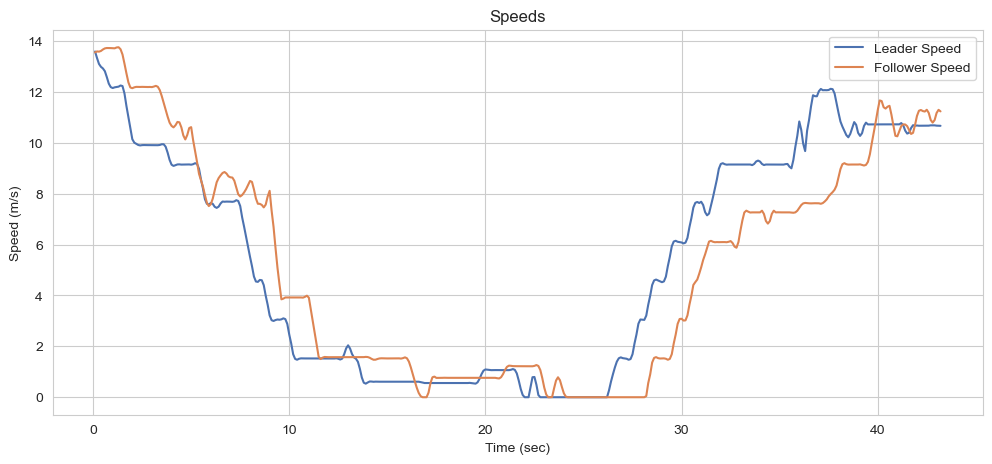

In [7]:
matt.figure(figsize = (12,5))
sns.lineplot(data = trajectory, x = 'Time', y = 'leader_speed(m/s)', label = 'Leader Speed')
sns.lineplot(data = trajectory, x = 'Time', y = 'follower_speed(m/s)', label = 'Follower Speed')

matt.xlabel('Time (sec)')
matt.ylabel('Speed (m/s)')
matt.title('Speeds')
matt.legend()
matt.show()

# Simulation Study Using the Intelligent Driver Model (IDM)

In [8]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
       
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    
    return acceleration

In [9]:
ngsim = pd.read_csv('NGSIM(in).csv')

# Select a trajectory pair
trajID = 10
traj = ngsim[ngsim['trajectory_number'] == trajID].reset_index(drop = True)

# Extract the leader's position and speed over time
time = traj['Time'].values
leadPos = traj['leader_position(m)'].values
leadSpeed = traj['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 # seconds

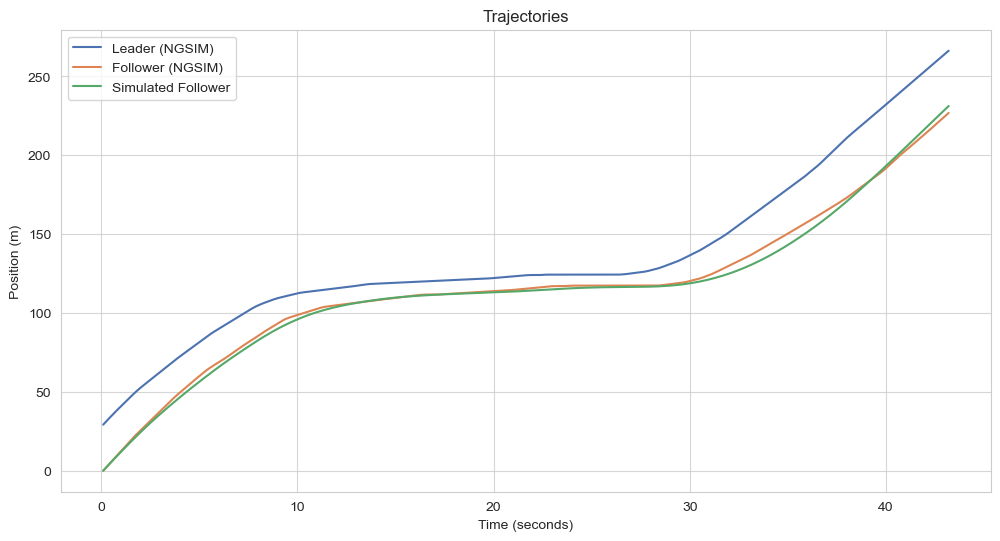

In [31]:
# Set the IDM parameters
v0 = 30   # desired velocity (m/s)
s0 = 8    # minimum spacing (m)
T = 2  # desired time headway (s)
a = 1.5    # maximum acceleration (m/s^2)  
b = 2    # comfortable deceleration (m/s^2)
delta = 5  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time)        # number of simulation steps we will take, which will be equal to the length of the trajectory data
simPos = np.zeros(n_steps)        # simulated follower position; we will create a vector with all zeroes  as a start
simSpeed = np.zeros(n_steps)       # simulated follower speed; we will create a vector with all zeroes  as a start
simAccel = np.zeros(n_steps)        # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
simPos[0] = traj['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle positionsi
simSpeed[0] = traj['follower_speed(m/s)'].values[0]             #this makes the starting value [0] same as the follower vehicle speed


for i in range(n_steps - 1): # n-1 since the first element is known 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leadPos[i] - simPos[i], 0.1)
    delta_v = simSpeed[i] - leadSpeed[i]
    
    # Step 3: Use the IDM function to calculate acceleration
    simAccel[i] = idm_acceleration(simSpeed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    simSpeed[i+1] = max(simSpeed[i] + simAccel[i] * dt, 0)
    simPos[i+1] = simPos[i] + simSpeed[i] * dt


matt.figure(figsize = (12,6))
matt.plot(time, leadPos, label = 'Leader (NGSIM)')
matt.plot(time, traj['follower_position(m)'], label = 'Follower (NGSIM)')
matt.plot(time, simPos, label = 'Simulated Follower')
matt.title('Trajectories')
matt.xlabel('Time (seconds)')
matt.ylabel('Position (m)')
matt.legend()
matt.grid(True, alpha = 0.8)
matt.show()